Initial EDA

In [5]:
import pandas as pd
import duckdb 
import matplotlib.pyplot as plt

df = pd.read_csv('../data_files/alvsjo_data.csv')

df

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,Konstfack,university,Skola,LM Ericssons Väg,14,59.299773,17.994210
1,Marino,restaurant,Restaurang,Klubbacken,51,59.305325,17.963290
2,Hemköp Stockholm Älvsjö,supermarket,Matbutik,Sjättenovembervägen,208,59.278752,18.002280
3,NaN,parking,Parkering,NaN,NaN,59.292349,17.985708
4,McDonald's,fast_food,Snabbmat,NaN,NaN,59.293074,18.001211
...,...,...,...,...,...,...,...
820,NaN,parking,Parkering,NaN,NaN,59.301074,18.011193
821,NaN,parking,Parkering,NaN,NaN,59.304636,18.029399
822,Aspuddens skola,school,Skola,Blommensbergsvägen,166,59.309309,17.997874
823,NaN,parking,Parkering,NaN,NaN,59.309750,18.029463


In [6]:
df.columns

Index(['Namn', 'Typ', 'Kategori', 'Gata', 'Nr', 'Lat', 'Lon'], dtype='str')

In [7]:
df.describe()

,Lat,Lon
count,825.000000,825.000000
mean,59.294621,17.994793
std,0.011368,0.023371
min,59.264904,17.942848
25%,59.285472,17.974856
50%,59.294183,17.999042
75%,59.304445,18.012308
max,59.317949,18.036724


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Namn      450 non-null    str    
 1   Typ       825 non-null    str    
 2   Kategori  825 non-null    str    
 3   Gata      135 non-null    str    
 4   Nr        131 non-null    str    
 5   Lat       825 non-null    float64
 6   Lon       825 non-null    float64
dtypes: float64(2), str(5)
memory usage: 45.2 KB


Check for null values

In [9]:
duckdb.sql(
    """--sql
    SELECT * FROM df
    WHERE Namn IS NULL OR Typ IS NULL OR Kategori IS NULL OR Gata IS NULL OR Nr IS NULL or Lat IS NULL or Lon IS NULL
    """
).df().head()

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,NaN,parking,Parkering,NaN,NaN,59.292349,17.985708
1,McDonald's,fast_food,Snabbmat,NaN,NaN,59.293074,18.001211
2,Sushi Bar,restaurant,Restaurang,NaN,NaN,59.292424,17.967934
3,NaN,parking,Parkering,NaN,NaN,59.264904,17.983771
4,NaN,parking,Parkering,NaN,NaN,59.271886,17.999430


Kolla efter dubletter

<Axes: xlabel='Namn'>

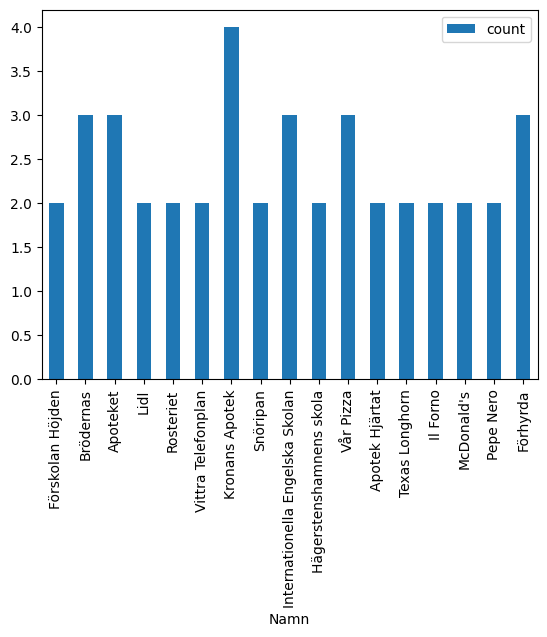

In [10]:
duckdb.sql(
    """--sql
        SELECT Namn, COUNT(*) as count
        FROM df
        WHERE NOT NAMN IS NULL
        GROUP BY Namn
        HAVING COUNT(*) > 1;
    """).df().plot(kind='bar', x='Namn', y='count') 

Dubletter som troligen är samma 

In [11]:
duckdb.sql(
    """---sql
    SELECT Namn, 
           ROUND(Lat, 3) as lat_r, 
           ROUND(Lon, 3) as lon_r, 
           COUNT(*) as count
    FROM df
    WHERE Namn IS NOT NULL
    GROUP BY Namn, ROUND(Lat, 3), ROUND(Lon, 3)
    HAVING COUNT(*) > 1
"""
).df()

,Namn,lat_r,lon_r,count
0,Förskolan Höjden,59.304,18.032,2


Kolla antal platser per kategori

<Axes: xlabel='Kategori'>

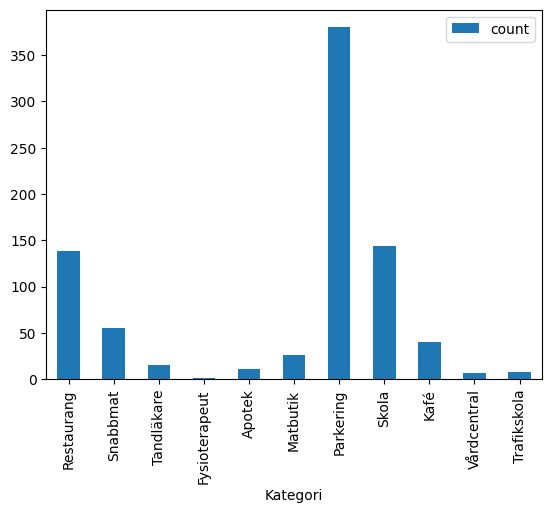

In [12]:
duckdb.sql(
    """--sql
    SELECT Kategori, COUNT(*) as count
    FROM df
    GROUP BY Kategori
    """).df().plot(kind='bar', x='Kategori', y='count')

Kolla var gatunamn inte finns

In [13]:
duckdb.sql(
    """--sql
    SELECT Gata, COUNT(*) as count
    FROM df
    WHERE Gata IS NULL
    GROUP BY Gata
    """).df()   

,Gata,count
0,None,690


EDA on skolor.csv

In [14]:
df2 = pd.read_csv('../data_files/skolor.csv')

df2

,id,kategori,namn,gatuadress,postnummer,stad,koordinat_east,koordinat_north
0,15106,grundskolor,"Apolloniosskolan, F–9",Stora Mans väg 11B,12559,Älvsjö,148591,6573949
1,13499,grundskolor,"Aspuddens skola, F–9",Blommensbergsvägen 166,12655,Hägersten,149899,6577119
2,15258,grundskolor,"Fruängens skola, F–9",Fruängsgatan 57–61,12953,Hägersten,147876,6574395
3,15196,grundskolor,"Grundskolan Metapontum, F–9",Stora Mans väg 11C,12559,Älvsjö,148607,6573925
4,13877,grundskolor,"Herrängens skola, F–6",Konvaljestigen 15,12555,Älvsjö,148419,6573321
...,...,...,...,...,...,...,...,...
129,10557,förskola,Älvens Förskola,Älvsjö gårdsväg 3–9,12542,Älvsjö,150554,6573532
130,9639,förskola,Älvsjö förskola,Långbrodalsvägen 1,12532,Älvsjö,150109,6573809
131,7834,förskola,Älvsjöbarnen,Murgrönsvägen 17,12555,Älvsjö,148168,6573488
132,6792,förskola,Älvskogen,Långsjövägen 33,12530,Älvsjö,149677,6573107


In [15]:
df2.describe()

,id,postnummer,koordinat_east,koordinat_north
count,134.000000,134.000000,134.000000,1.340000e+02
mean,11493.500000,12692.791045,149539.253731,6.575023e+06
std,5072.750304,160.309760,1221.475926,1.277810e+03
min,6645.000000,12530.000000,147000.000000,6.572317e+06
25%,8639.250000,12558.250000,148596.500000,6.574001e+06
50%,9971.500000,12638.000000,149474.000000,6.574880e+06
75%,14425.250000,12932.000000,150353.250000,6.576045e+06
max,34879.000000,12957.000000,152359.000000,6.579164e+06


In [16]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               134 non-null    int64
 1   kategori         134 non-null    str  
 2   namn             134 non-null    str  
 3   gatuadress       134 non-null    str  
 4   postnummer       134 non-null    int64
 5   stad             134 non-null    str  
 6   koordinat_east   134 non-null    int64
 7   koordinat_north  134 non-null    int64
dtypes: int64(4), str(4)
memory usage: 8.5 KB
